In [1]:
import argparse
import os

import pandas as pd
import pickle
from tqdm import tqdm
from copy import deepcopy

import numpy as np
import torch
from torch import optim
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt

import sys

/var/folders/v8/8_pync_n0_vf_5wr12y0p8vh0000gn/T/ipykernel_15947/2885020534.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# top r svd
def top_r_svd(A, r):
    V, S, Vt = torch.linalg.svd(A, full_matrices=True)

    Vr = V[:, :r]  
    Sr = S[:r]   
    Vtr = Vt[:r, :]
    return Vr, Sr, Vtr

# norm by dividing the max singular value
def svd_norm(A):
    U, S, V = torch.svd(A)

    S_normalized = S / S.max()
    scale = S.max()

    A_normalized = U @ torch.diag(S_normalized) @ V.t()

    return A_normalized, scale

# norm by UV
def uv_norm(A):
    U, S, V = torch.svd(A)

    A_normalized = U @ V.t()

    return A_normalized

# reverse norm by multipying the max singular value
def svd_norm_reverse(A, scale):
    U, S, V = torch.svd(A)

    S_reverse = S * scale

    A_normalized = U @ torch.diag(S_reverse) @ V.t()

    return A_normalized

In [3]:
d1 = 300
r = 1
d2 = 10

mat1 = torch.randn(d1, r)
mat2 = torch.randn(r, d2)
M = mat1 @ mat2

# r = mat2.shape[0]


p_prime = 0.75
p = 1 - p_prime
noise = 0.00
dataset = 'random'

print(mat2)

tensor([[-1.4048, -0.7999,  1.0153,  0.7558,  0.8443, -0.7179,  0.9466, -0.7425,
          0.9077, -0.6176]])


/var/folders/v8/8_pync_n0_vf_5wr12y0p8vh0000gn/T/ipykernel_15947/997121084.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(MTM, requires_grad=True)


norm of M: 49.30881881713867


100%|██████████| 3000/3000 [00:01<00:00, 2224.09it/s, In epoch 2999, loss: 2332.079)]


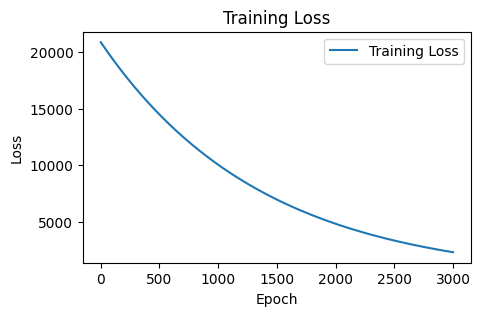

In [15]:
"""
Train for X
"""
# observed M & norm
mask = torch.bernoulli(torch.full((M.shape[0],), p)).bool()
observed_M = deepcopy(M)
observed_M[mask] = 0 # mask user
#observed_M = M
#observed_M_norm, scale_M = svd_norm(observed_M) # svd norm
MTM = observed_M.t() @ observed_M


scale_diag = (p_prime - 1) / (p_prime ** 2) * torch.diag(MTM).diag() # objective matrix
A = scale_diag + 1 / (p_prime ** 2) * MTM

print(f"norm of M: {torch.norm(M)}")

# parameters setting
d1, d2 = observed_M.shape
#X = torch.randn(d2, d2, requires_grad=True)
X = torch.tensor(MTM, requires_grad=True)

epochs = 5000
alpha = 0.05

loop = tqdm(range(epochs))
eta = 1 / np.sqrt(epochs)
optimizer = optim.SGD([X], lr=eta)

# opt
train_losses = []
writer = SummaryWriter('runs/'+dataset)
for i in loop:
    loss = ((X - A)**2).mean() # mse loss
    U, D, Vt = torch.linalg.svd(X, full_matrices=False)
    loss.backward()

    noise_matrix = torch.normal(mean=0, std=noise, size=(d2, d2))

    X.grad = X.grad + alpha * U @ Vt + noise_matrix # alg
    """
    with torch.no_grad():
        X.data += -eta*X.grad
    """
    optimizer.step()
    X.grad.zero_()
    #print(loss.item())
    writer.add_scalar('Loss', loss.item(), i)
    train_losses.append(loss.item())
    loop.set_postfix_str('In epoch {}, loss: {:.3f})'.format(i, loss.item()))

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()



In [16]:
"""
normalization for result
"""
#X, _ = svd_norm(X)
u, d, vt = torch.linalg.svd(X)
#X = vt.t() @ vt

err = X - M.T @ M

#print(f"x - mtm: {X - M.T @ M}")

print(torch.norm(err), torch.norm(M.T @ M))

#print(f"norm of X: {torch.norm(X)}")
#print(f"norm of M: {torch.norm(M.T @ M)}")


tensor(510.2599, grad_fn=<LinalgVectorNormBackward0>) tensor(2431.3599)


In the case r=1, use every column to recover M independently. If M can be retrieved, the result should be similar in every column.

In [6]:
"""
recover M
"""
_, S, item_vector = top_r_svd(X, r)
predict_matrix = []
miss_item_u = []
print(M.shape)
for i in range(5):
    M_u = M[i] # get objective row

    print(f"M_u: {M_u}")
    print(f"item_vector: {item_vector}")
    print(f"user_value: {M_u/item_vector}")
    print()



torch.Size([300, 10])
M_u: tensor([-0.4443, -0.2530,  0.3212,  0.2391,  0.2671, -0.2271,  0.2994, -0.2349,
         0.2871, -0.1954])
item_vector: tensor([[-0.4827, -0.2838,  0.3568,  0.2686,  0.2990, -0.2554,  0.3337, -0.2640,
          0.3206, -0.2205]], grad_fn=<SliceBackward0>)
user_value: tensor([[0.9206, 0.8917, 0.9001, 0.8902, 0.8932, 0.8890, 0.8972, 0.8897, 0.8956,
         0.8861]], grad_fn=<DivBackward0>)

M_u: tensor([ 0.3271,  0.1862, -0.2364, -0.1760, -0.1966,  0.1671, -0.2204,  0.1729,
        -0.2113,  0.1438])
item_vector: tensor([[-0.4827, -0.2838,  0.3568,  0.2686,  0.2990, -0.2554,  0.3337, -0.2640,
          0.3206, -0.2205]], grad_fn=<SliceBackward0>)
user_value: tensor([[-0.6776, -0.6563, -0.6626, -0.6552, -0.6575, -0.6544, -0.6604, -0.6549,
         -0.6593, -0.6522]], grad_fn=<DivBackward0>)

M_u: tensor([-2.5127, -1.4307,  1.8161,  1.3519,  1.5101, -1.2840,  1.6932, -1.3281,
         1.6236, -1.1047])
item_vector: tensor([[-0.4827, -0.2838,  0.3568,  0.2686,  0

In [7]:
mat1 = torch.randn(100, 1)
mat2 = torch.randn(1, 3)
m = mat1 @ mat2

u, d, vt = torch.linalg.svd(mat2)
print(d)
print(vt)
#m = vt.t() @ vt # norm the highest singular value to 1?

u, d, vt = top_r_svd(m, r=1)
vt = vt / torch.norm(vt, p=2)

print(f"mat2: {mat2}")
print(f"vt: {vt}")

u, d, vt = torch.linalg.svd(m)
print(vt)
print(d)

tensor([0.7746])
tensor([[-0.6483,  0.5677, -0.5074],
        [ 0.5677,  0.8045,  0.1747],
        [-0.5074,  0.1747,  0.8438]])
mat2: tensor([[-0.5022,  0.4397, -0.3930]])
vt: tensor([[ 0.6483, -0.5677,  0.5074]])
tensor([[ 0.6483, -0.5677,  0.5074],
        [-0.7571, -0.5514,  0.3504],
        [-0.0809,  0.6113,  0.7873]])
tensor([7.6429e+00, 2.7385e-07, 8.7115e-08])


In [8]:
X

tensor([[ 586.1400,  414.5674, -526.2251, -391.7171, -437.5732,  372.0613,
         -490.6215,  384.8177, -470.4551,  320.1051],
        [ 414.5674,  190.0444, -299.6389, -223.0486, -249.1594,  211.8562,
         -279.3661,  219.1201, -267.8829,  182.2719],
        [-526.2251, -299.6389,  306.2013,  283.1232,  316.2668, -268.9163,
          354.6088, -278.1367,  340.0327, -231.3641],
        [-391.7171, -223.0486,  283.1232,  169.6719,  235.4262, -200.1792,
          263.9680, -207.0427,  253.1178, -172.2253],
        [-437.5732, -249.1594,  316.2668,  235.4262,  211.7220, -223.6127,
          294.8690, -231.2799,  282.7486, -192.3868],
        [ 372.0613,  211.8562, -268.9163, -200.1792, -223.6127,  153.0712,
         -250.7223,  196.6535, -240.4166,  163.5833],
        [-490.6215, -279.3661,  354.6088,  263.9680,  294.8690, -250.7223,
          266.1694, -259.3188,  317.0276, -215.7103],
        [ 384.8177,  219.1201, -278.1367, -207.0427, -231.2799,  196.6535,
         -259.3188,  1

In [9]:
M.T @ M

tensor([[ 592.6108,  337.4398, -428.3240, -318.8407, -356.1655,  302.8416,
         -399.3448,  313.2252, -382.9301,  260.5517],
        [ 337.4398,  192.1424, -243.8929, -181.5519, -202.8050,  172.4418,
         -227.3919,  178.3543, -218.0452,  148.3614],
        [-428.3240, -243.8929,  309.5817,  230.4500,  257.4273, -218.8862,
          288.6363, -226.3912,  276.7722, -188.3202],
        [-318.8407, -181.5519,  230.4500,  171.5450,  191.6267, -162.9370,
          214.8584, -168.5237,  206.0268, -140.1839],
        [-356.1655, -202.8050,  257.4273,  191.6267,  214.0593, -182.0111,
          240.0106, -188.2517,  230.1451, -156.5944],
        [ 302.8416,  172.4418, -218.8862, -162.9370, -182.0111,  154.7610,
         -204.0770,  160.0673, -195.6886,  133.1496],
        [-399.3448, -227.3919,  288.6363,  214.8584,  240.0106, -204.0770,
          269.1080, -211.0742,  258.0467, -175.5789],
        [ 313.2252,  178.3543, -226.3912, -168.5237, -188.2517,  160.0673,
         -211.0742,  1

In [10]:
A

tensor([[ 639.5983,  485.5935, -616.3804, -458.8283, -512.5406,  435.8048,
         -574.6780,  450.7472, -551.0563,  374.9472],
        [ 485.5935,  207.3772, -350.9747, -261.2626, -291.8469,  248.1526,
         -327.2288,  256.6611, -313.7783,  213.4997],
        [-616.3804, -350.9747,  334.1281,  331.6295,  370.4513, -314.9887,
          415.3626, -325.7887,  398.2895, -271.0025],
        [-458.8283, -261.2626,  331.6295,  185.1466,  275.7608, -234.4749,
          309.1924, -242.5143,  296.4833, -201.7319],
        [-512.5406, -291.8469,  370.4513,  275.7608,  231.0318, -261.9234,
          345.3877, -270.9040,  331.1909, -225.3475],
        [ 435.8048,  248.1526, -314.9887, -234.4749, -261.9234,  167.0319,
         -293.6774,  230.3452, -281.6061,  191.6092],
        [-574.6780, -327.2288,  415.3626,  309.1924,  345.3877, -293.6774,
          290.4453, -303.7468,  371.3425, -252.6672],
        [ 450.7472,  256.6611, -325.7887, -242.5143, -270.9040,  230.3452,
         -303.7468,  1

In [11]:
observed_M.T @ observed_M

tensor([[ 479.6987,  273.1464, -346.7140, -258.0909, -288.3041,  245.1402,
         -323.2563,  253.5453, -309.9692,  210.9078],
        [ 273.1464,  155.5329, -197.4232, -146.9602, -164.1639,  139.5859,
         -184.0662,  144.3719, -176.5003,  120.0936],
        [-346.7140, -197.4232,  250.5961,  186.5416,  208.3789, -177.1811,
          233.6415, -183.2561,  224.0378, -152.4389],
        [-258.0909, -146.9602,  186.5416,  138.8600,  155.1154, -131.8921,
          173.9207, -136.4143,  166.7719, -113.4742],
        [-288.3041, -164.1639,  208.3789,  155.1154,  173.2739, -147.3319,
          194.2806, -152.3835,  186.2949, -126.7580],
        [ 245.1402,  139.5859, -177.1811, -131.8921, -147.3319,  125.2739,
         -165.1936,  129.5692, -158.4034,  107.7802],
        [-323.2563, -184.0662,  233.6415,  173.9207,  194.2806, -165.1936,
          217.8340, -170.8576,  208.8802, -142.1253],
        [ 253.5453,  144.3719, -183.2561, -136.4143, -152.3835,  129.5692,
         -170.8576,  1

In [12]:
M

tensor([[-0.4443, -0.2530,  0.3212,  ..., -0.2349,  0.2871, -0.1954],
        [ 0.3271,  0.1862, -0.2364,  ...,  0.1729, -0.2113,  0.1438],
        [-2.5127, -1.4307,  1.8161,  ..., -1.3281,  1.6236, -1.1047],
        ...,
        [-2.0983, -1.1948,  1.5166,  ..., -1.1091,  1.3559, -0.9226],
        [-0.5629, -0.3205,  0.4068,  ..., -0.2975,  0.3637, -0.2475],
        [ 0.0445,  0.0254, -0.0322,  ...,  0.0235, -0.0288,  0.0196]])